# ICP Dataset Exploration
**MLOps LK-02 | Data Ingestion & Analysis**

Loads the ingested `icp_dataset.csv` and explores ICP price trends.

## 0. Setup

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

print('Setup complete.')

Setup complete.


## 1. Load Dataset

In [2]:
dataset_path = project_root / 'data' / 'processed' / 'icp_dataset.csv'

df = pd.read_csv(dataset_path)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').reset_index(drop=True)

print(f'Rows: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Rows: 9
Columns: ['date', 'icp_price']


,date,icp_price
0,2019-01-01,56.55
1,2019-04-01,68.31
2,2019-05-01,68.07
3,2020-02-01,56.61
4,2020-03-01,34.23
5,2020-04-01,20.66
6,2020-07-01,40.64
7,2023-01-01,78.54
8,2024-01-01,77.12


## 2. Dataset Summary

In [3]:
print('=== Info ===')
df.info()
print('\n=== Statistics ===')
print(df.describe())
print(f'\nDate range: {df["date"].min().date()} \u2192 {df["date"].max().date()}')
print(f'Missing values:\n{df.isnull().sum()}')

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       9 non-null      datetime64[ns]
 1   icp_price  9 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 272.0 bytes

=== Statistics ===
                      date  icp_price
count                    9   9.000000
mean   2020-08-14 05:20:00  55.636667
min    2019-01-01 00:00:00  20.660000
25%    2019-05-01 00:00:00  40.640000
50%    2020-03-01 00:00:00  56.610000
75%    2020-07-01 00:00:00  68.310000
max    2024-01-01 00:00:00  78.540000
std                    NaN  20.029951

Date range: 2019-01-01 → 2024-01-01
Missing values:
date         0
icp_price    0
dtype: int64


## 3. ICP Price Trend

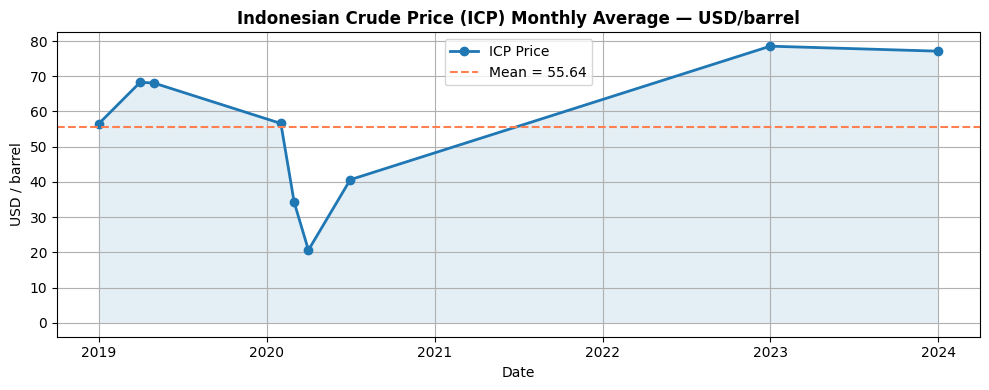

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(df['date'], df['icp_price'], marker='o', linewidth=2, label='ICP Price')
plt.fill_between(df['date'], df['icp_price'], alpha=0.12)
plt.axhline(df['icp_price'].mean(), color='coral', linestyle='--',
            label=f'Mean = {df["icp_price"].mean():.2f}')
plt.title('Indonesian Crude Price (ICP) Monthly Average — USD/barrel', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('USD / barrel')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Year-over-Year Box Plot

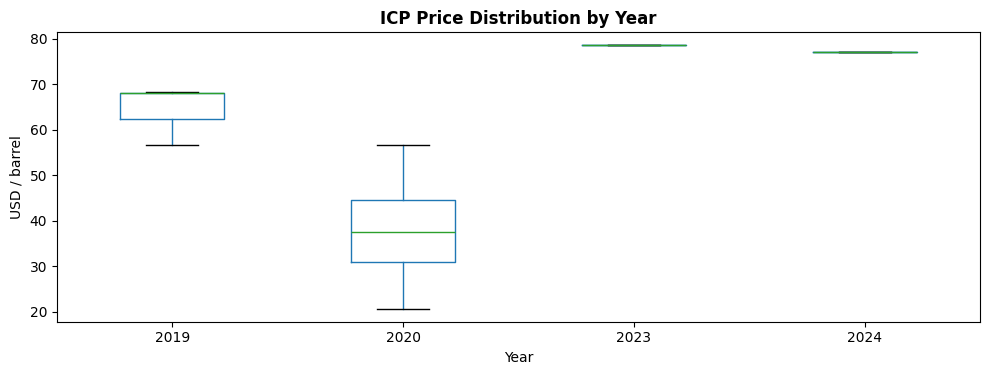

In [5]:
df['year'] = df['date'].dt.year

fig, ax = plt.subplots(figsize=(10, 4))
df.boxplot(column='icp_price', by='year', ax=ax, grid=False)
ax.set_title('ICP Price Distribution by Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('USD / barrel')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Rolling Averages

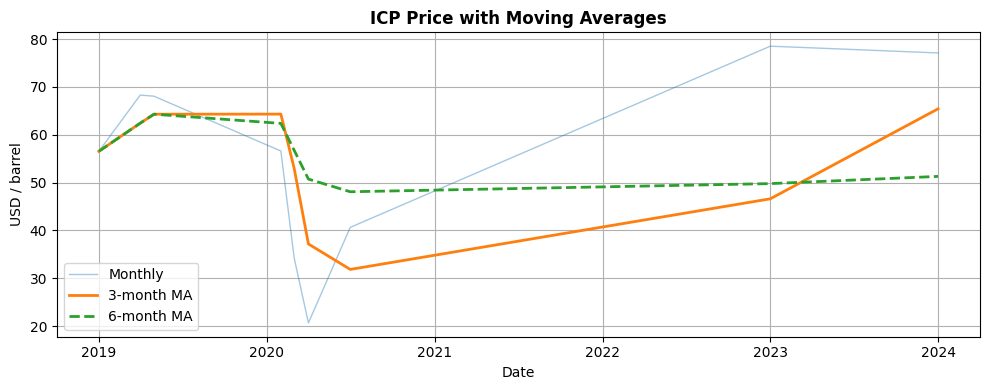

In [6]:
df['rolling_3m'] = df['icp_price'].rolling(3, min_periods=1).mean()
df['rolling_6m'] = df['icp_price'].rolling(6, min_periods=1).mean()

plt.figure(figsize=(10, 4))
plt.plot(df['date'], df['icp_price'], alpha=0.4, label='Monthly', linewidth=1)
plt.plot(df['date'], df['rolling_3m'], linewidth=2, label='3-month MA')
plt.plot(df['date'], df['rolling_6m'], linewidth=2, label='6-month MA', linestyle='--')
plt.title('ICP Price with Moving Averages', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('USD / barrel')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Rebuild Dataset

To rebuild the dataset from `data/raw/` PDFs, run:
```bash
python src/data_processing/rebuild_dataset.py
```